In [52]:
# warnings
import warnings
warnings.filterwarnings('ignore')

In [53]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

In [54]:
pallete = 'ch:start=.2,rot=-.3'

### Reading Data

In [55]:
data = pd.read_csv('data.csv')
data.drop(columns=['ID'], inplace=True)
data.columns = data.columns.str.replace('_', ' ').str.replace('.', '_').str.title().str.strip().str.replace(' ', '_')

In [56]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10999 entries, 0 to 10998
Data columns (total 11 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   Warehouse_Block      10999 non-null  object 
 1   Mode_Of_Shipment     10999 non-null  object 
 2   Customer_Care_Calls  10999 non-null  int64  
 3   Customer_Rating      10999 non-null  int64  
 4   Cost_Of_The_Product  10901 non-null  float64
 5   Prior_Purchases      10999 non-null  int64  
 6   Product_Importance   10845 non-null  object 
 7   Gender               10999 non-null  object 
 8   Discount_Offered     10999 non-null  int64  
 9   Weight_In_Gms        10860 non-null  float64
 10  Reached_On_Time_Y_N  10999 non-null  int64  
dtypes: float64(2), int64(5), object(4)
memory usage: 945.4+ KB


Missing value imputation

In [57]:
data.isna().sum()

Warehouse_Block          0
Mode_Of_Shipment         0
Customer_Care_Calls      0
Customer_Rating          0
Cost_Of_The_Product     98
Prior_Purchases          0
Product_Importance     154
Gender                   0
Discount_Offered         0
Weight_In_Gms          139
Reached_On_Time_Y_N      0
dtype: int64

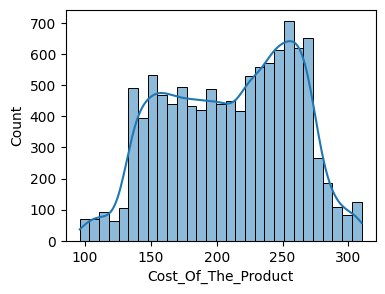

In [58]:
fig = plt.figure(figsize=(4,3))
sns.histplot(data=data, x='Cost_Of_The_Product', kde=True, fill=True)
plt.show()

In [59]:
data.Cost_Of_The_Product.fillna(data.Cost_Of_The_Product.median(), inplace=True)

In [60]:
data.Product_Importance.fillna(data.Product_Importance.mode()[0], inplace=True)

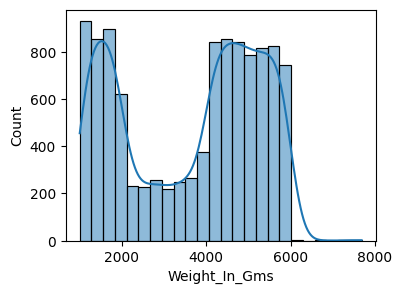

In [61]:
fig = plt.figure(figsize=(4,3))
sns.histplot(data=data, x='Weight_In_Gms', kde=True, fill=True)
plt.show()

In [62]:
data.Weight_In_Gms.fillna(data.Weight_In_Gms.median(), inplace=True)

### Exploring Data

Exploring Categorical Variables

In [63]:
categorical_variables = ['Warehouse_Block', 'Mode_Of_Shipment', 'Product_Importance', 'Gender']

Warehouse Block

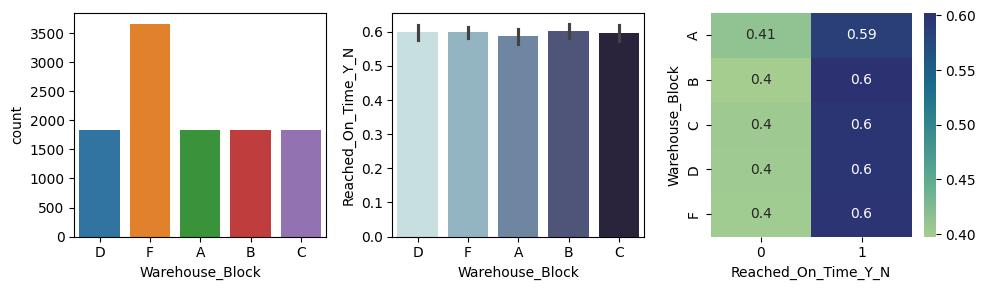

In [64]:
fig = plt.figure(figsize=(10, 3))
plt.subplot(1, 3, 1)
sns.countplot(data=data, x='Warehouse_Block', hue='Warehouse_Block')
plt.subplot(1, 3, 2)
sns.barplot(data=data, x='Warehouse_Block', y='Reached_On_Time_Y_N', palette=pallete)
plt.subplot(1, 3, 3)
sns.heatmap(pd.crosstab(data.Warehouse_Block, data.Reached_On_Time_Y_N, normalize='index'), annot=True, cmap='crest')
plt.tight_layout()
plt.show()

Mode Of Shipment

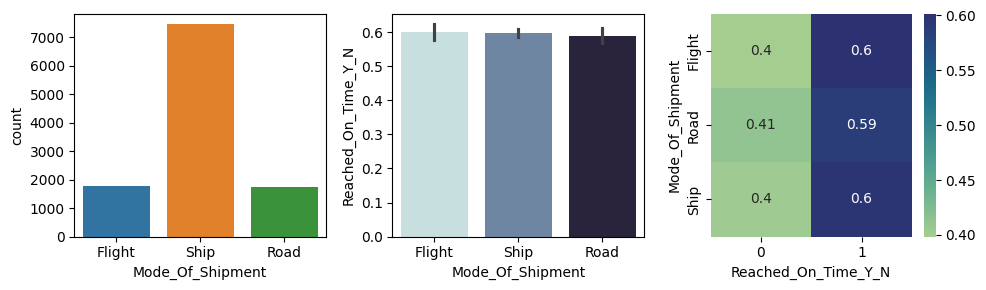

In [65]:
fig = plt.figure(figsize=(10, 3))
plt.subplot(1, 3, 1)
sns.countplot(data=data, x='Mode_Of_Shipment', hue='Mode_Of_Shipment')
plt.subplot(1, 3, 2)
sns.barplot(data=data, x='Mode_Of_Shipment', y='Reached_On_Time_Y_N', palette=pallete)
plt.subplot(1, 3, 3)
sns.heatmap(pd.crosstab(data.Mode_Of_Shipment, data.Reached_On_Time_Y_N, normalize='index'), annot=True, cmap='crest')
plt.tight_layout()
plt.show()

Product Importance

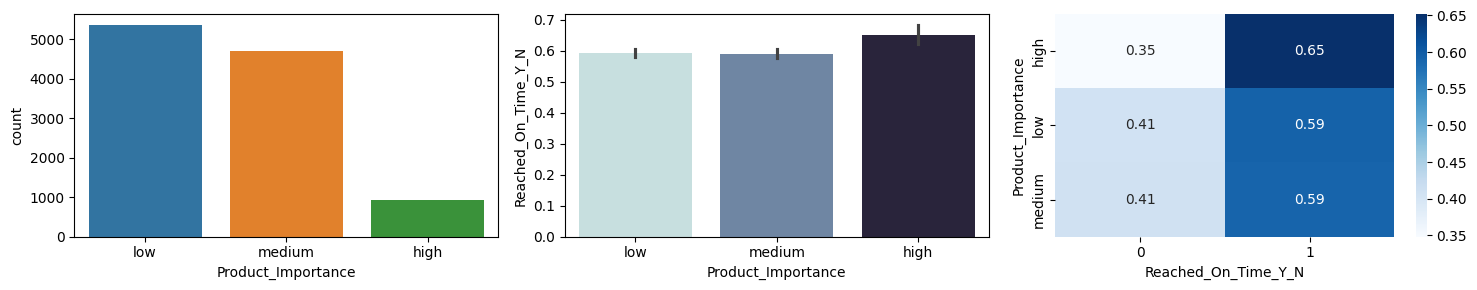

In [66]:
fig = plt.figure(figsize=(15, 3))
plt.subplot(1, 3, 1)
sns.countplot(data=data, x='Product_Importance', hue='Product_Importance')
plt.subplot(1, 3, 2)
sns.barplot(data=data, x='Product_Importance', y='Reached_On_Time_Y_N', palette=pallete)
plt.subplot(1, 3, 3)
sns.heatmap(pd.crosstab(data.Product_Importance, data.Reached_On_Time_Y_N, normalize='index'), annot=True, cmap='Blues')
plt.tight_layout()
plt.show()

Gender

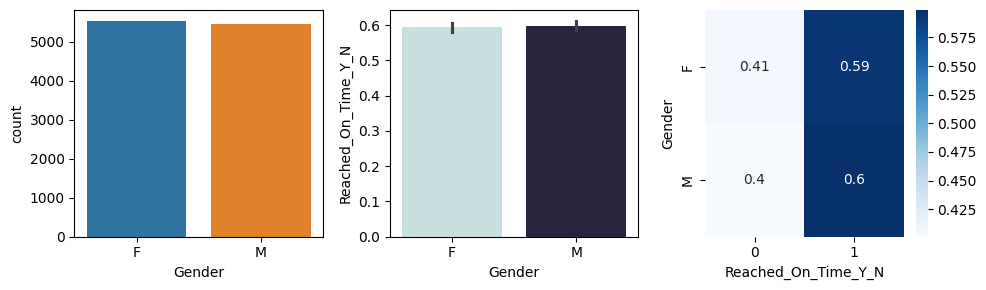

In [67]:
fig = plt.figure(figsize=(10, 3))
plt.subplot(1, 3, 1)
sns.countplot(data=data, x='Gender', hue='Gender')
plt.subplot(1, 3, 2)
sns.barplot(data=data, x='Gender', y='Reached_On_Time_Y_N', palette=pallete)
plt.subplot(1, 3, 3)
sns.heatmap(pd.crosstab(data.Gender, data.Reached_On_Time_Y_N, normalize='index'), annot=True, cmap='Blues')
plt.tight_layout()
plt.show()

Exploring Numerical Variables

In [68]:
numerical_columns = ['Customer_Care_Calls', 'Customer_Rating', 'Cost_Of_The_Product', 'Prior_Purchases', 'Discount_Offered', 'Weight_In_Gms', 'Reached_On_Time_Y_N']

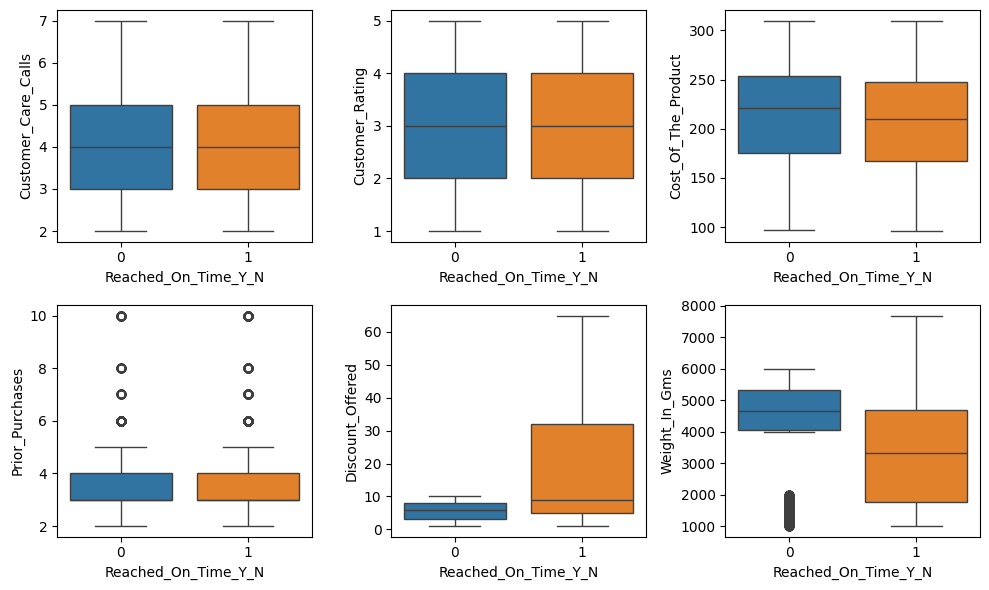

In [69]:
fig = plt.figure(figsize=(10, 6))
plt.subplot(2, 3, 1)
sns.boxplot(data=data, y='Customer_Care_Calls', x='Reached_On_Time_Y_N', hue='Reached_On_Time_Y_N', legend=False)
plt.subplot(2, 3, 2)
sns.boxplot(data=data, y='Customer_Rating', x='Reached_On_Time_Y_N', hue='Reached_On_Time_Y_N', legend=False)
plt.subplot(2, 3, 3)
sns.boxplot(data=data, y='Cost_Of_The_Product', x='Reached_On_Time_Y_N', hue='Reached_On_Time_Y_N', legend=False)
plt.subplot(2, 3, 4)
sns.boxplot(data=data, y='Prior_Purchases', x='Reached_On_Time_Y_N', hue='Reached_On_Time_Y_N', legend=False)
plt.subplot(2, 3, 5)
sns.boxplot(data=data, y='Discount_Offered', x='Reached_On_Time_Y_N', hue='Reached_On_Time_Y_N', legend=False)
plt.subplot(2, 3, 6)
sns.boxplot(data=data, y='Weight_In_Gms', x='Reached_On_Time_Y_N', hue='Reached_On_Time_Y_N', legend=False)
plt.tight_layout()
plt.show()

In [70]:
# Features showing relationshipt with state of shipment
# Cost of product
# Discount
# Weight

Correlation

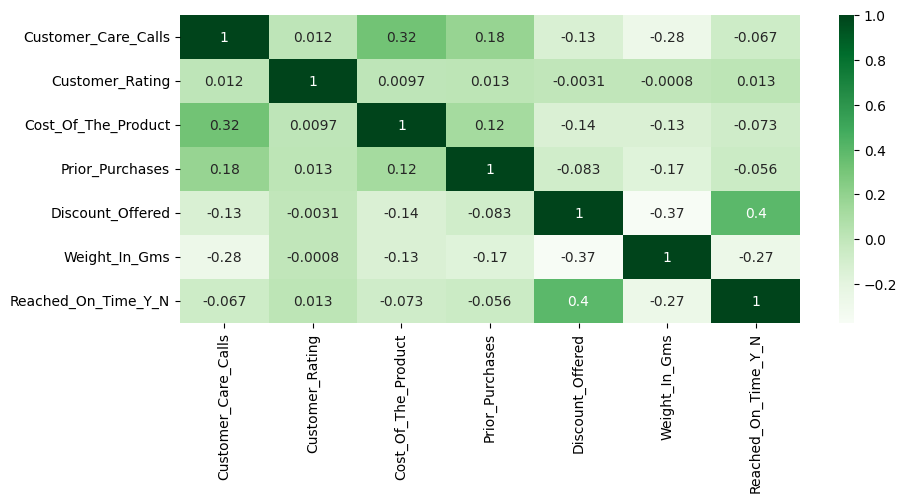

In [71]:
fig = plt.figure(figsize=(10, 4))
sns.heatmap(data[numerical_columns].corr(), annot=True, cmap='Greens')
plt.show()

Creating Features

In [72]:
categorical_variables.remove('Gender')

In [73]:
featured_data = pd.get_dummies(data=data, columns=categorical_variables).replace({True: 1, False: 0})

Gender

In [74]:
gender_map = {'M': 1, 'F': 0}
featured_data.Gender = featured_data.Gender.map(gender_map)

In [75]:
numerical_features = list(numerical_columns)
numerical_features.remove('Reached_On_Time_Y_N')

Splitting Data

In [76]:
from sklearn.model_selection import train_test_split
X_train, X_test = train_test_split(featured_data, train_size=0.7, test_size=0.3, random_state=42)
y_train = X_train.pop('Reached_On_Time_Y_N')
y_test = X_test.pop('Reached_On_Time_Y_N')

Scaling Data

In [77]:
from sklearn.preprocessing import MinMaxScaler

In [78]:
scaler = MinMaxScaler()

In [79]:
X_train[numerical_features] = scaler.fit_transform(X_train[numerical_features])
X_test[numerical_features] = scaler.transform(X_test[numerical_features])

In [80]:
X_train.describe()

,Customer_Care_Calls,Customer_Rating,Cost_Of_The_Product,Prior_Purchases,Gender,Discount_Offered,Weight_In_Gms,Warehouse_Block_A,Warehouse_Block_B,Warehouse_Block_C,Warehouse_Block_D,Warehouse_Block_F,Mode_Of_Shipment_Flight,Mode_Of_Shipment_Road,Mode_Of_Shipment_Ship,Product_Importance_high,Product_Importance_low,Product_Importance_medium
count,7699.000000,7699.000000,7699.000000,7699.000000,7699.000000,7699.000000,7699.000000,7699.000000,7699.000000,7699.000000,7699.000000,7699.000000,7699.000000,7699.000000,7699.000000,7699.000000,7699.000000,7699.000000
mean,0.413534,0.499643,0.535782,0.198695,0.500195,0.192844,0.397280,0.167294,0.165866,0.164956,0.169632,0.332251,0.163008,0.159241,0.677750,0.084556,0.488895,0.426549
std,0.230329,0.352829,0.224848,0.191233,0.500032,0.253016,0.245075,0.373263,0.371984,0.371165,0.375334,0.471051,0.369397,0.365925,0.467368,0.278239,0.499909,0.494608
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,0.200000,0.250000,0.345794,0.125000,0.000000,0.046875,0.126977,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,0.400000,0.500000,0.551402,0.125000,1.000000,0.093750,0.475448,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000
75%,0.600000,0.750000,0.724299,0.250000,1.000000,0.140625,0.606643,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,1.000000,0.000000,1.000000,1.000000
max,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000


In [81]:
X_test.describe()

,Customer_Care_Calls,Customer_Rating,Cost_Of_The_Product,Prior_Purchases,Gender,Discount_Offered,Weight_In_Gms,Warehouse_Block_A,Warehouse_Block_B,Warehouse_Block_C,Warehouse_Block_D,Warehouse_Block_F,Mode_Of_Shipment_Flight,Mode_Of_Shipment_Road,Mode_Of_Shipment_Ship,Product_Importance_high,Product_Importance_low,Product_Importance_medium
count,3300.000000,3300.000000,3300.000000,3300.000000,3300.000000,3300.000000,3300.000000,3300.000000,3300.000000,3300.000000,3300.000000,3300.000000,3300.000000,3300.000000,3300.000000,3300.000000,3300.000000,3300.000000
mean,0.404727,0.492955,0.529099,0.189545,0.485758,0.194470,0.402122,0.165152,0.168485,0.170606,0.160000,0.335758,0.158182,0.161818,0.680000,0.084545,0.486970,0.428485
std,0.223401,0.354740,0.220623,0.188173,0.499873,0.253701,0.244416,0.371374,0.374353,0.376221,0.366662,0.472326,0.364967,0.368340,0.466547,0.278246,0.499906,0.494934
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000301,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,0.200000,0.250000,0.345794,0.000000,0.000000,0.046875,0.131307,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,0.400000,0.500000,0.546729,0.125000,0.000000,0.093750,0.475448,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000
75%,0.600000,0.750000,0.714953,0.250000,1.000000,0.140625,0.612969,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,1.000000,0.000000,1.000000,1.000000
max,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.006628,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000


Data Imbalance

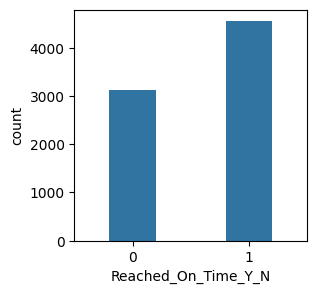

Reached_On_Time_Y_N
1    4575
0    3124
Name: count, dtype: int64

In [82]:
fig = plt.figure(figsize=(3, 3))
sns.barplot(y_train.value_counts(), width=0.4)
plt.show()
y_train.value_counts()

### Training & Evaluating Model

Training Model

In [83]:
from sklearn.neighbors import KNeighborsClassifier

In [84]:
knn_model = KNeighborsClassifier(n_neighbors=5)

In [85]:
knn_model.fit(X_train, y_train)

,n_neighbors,5
,weights,'uniform'
,algorithm,'auto'
,leaf_size,30
,p,2
,metric,'minkowski'
,metric_params,None
,n_jobs,None


Evaluating Model

In [86]:
from sklearn.metrics import accuracy_score, classification_report, roc_auc_score, roc_curve

In [87]:
predictions = knn_model.predict(X_test)

In [88]:
print("Classification Report:")
print(classification_report(y_test, predictions))

Classification Report:
              precision    recall  f1-score   support

           0       0.52      0.57      0.55      1312
           1       0.70      0.65      0.67      1988

    accuracy                           0.62      3300
   macro avg       0.61      0.61      0.61      3300
weighted avg       0.63      0.62      0.62      3300



In [89]:
fpr, tpr, thresholds = roc_curve(y_test, predictions)

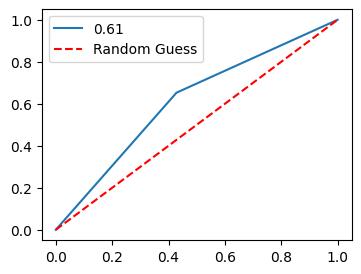

In [90]:
fig = plt.figure(figsize=(4, 3))
sns.lineplot(x=fpr, y=tpr, label=f"{roc_auc_score(y_test, predictions):.2f}")
sns.lineplot(x=[0,1], y=[0,1], linestyle='--', color='red', label='Random Guess')
plt.show()

### Optimal Value Of K

In [91]:
from sklearn.model_selection import cross_val_score

In [92]:
k_values = list(range(1, 21))
cv_scores = []

for k in k_values:
    knn = KNeighborsClassifier(n_neighbors=k)
    scores = cross_val_score(knn, X_train, y_train, cv=5, scoring='accuracy')
    cv_scores.append(scores.mean())

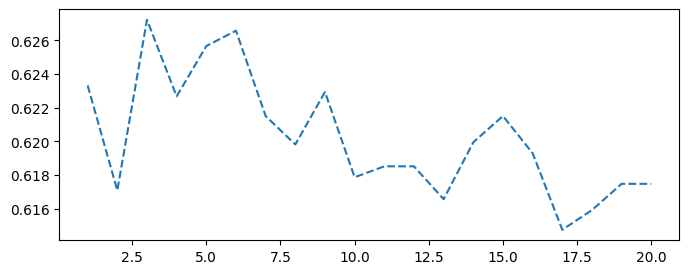

In [93]:
fig = plt.figure(figsize=(8, 3))
sns.lineplot(x=k_values, y=cv_scores, linestyle='--', markers=['x'])
plt.show()

In [94]:
optimal_k = k_values[np.argmax(cv_scores)]
print(f"Optimal value for k: {optimal_k}")

Optimal value for k: 3


### Hyper-Parameter tuning

In [95]:
from sklearn.model_selection import GridSearchCV

In [96]:
neighbour = list(range(3, 12, 2))
weight = ['uniform', 'distance']
metric = ['euclidean', 'manhattan', 'minkowski']

In [97]:
parameter_grid = {
    'n_neighbors': neighbour,
    'weights': weight,
    'metric': metric
}

In [98]:
grid_search = GridSearchCV(KNeighborsClassifier(), param_grid=parameter_grid, cv=5, scoring='accuracy')

In [99]:
grid_search.fit(X_train, y_train)

,estimator,KNeighborsClassifier()
,param_grid,"{'metric': ['euclidean', 'manhattan', ...], 'n_neighbors': [3, 5, ...], 'weights': ['uniform', 'distance']}"
,scoring,'accuracy'
,n_jobs,None
,refit,True
,cv,5
,verbose,0
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,n_neighbors,3


In [100]:
knn_model_b = grid_search.best_estimator_

In [101]:
y_pred = knn_model_b.predict(X_test)

Evaluating Best Model

In [102]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.53      0.56      0.54      1312
           1       0.70      0.67      0.68      1988

    accuracy                           0.63      3300
   macro avg       0.61      0.62      0.61      3300
weighted avg       0.63      0.63      0.63      3300

